# SmartSwipe — Assignment 1 (Completed Solutions)


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Q1

In [7]:
amounts = [120, 750, 300, 1800, 650, 450, 2500, 900]

def summarise(amounts, threshold):
    above = [x for x in amounts if x > threshold]
    above.sort(reverse=True)
    return {
        'above_threshold': above,
        'mean': sum(amounts)/len(amounts),
        'count_above': len(above)
    }

print(summarise(amounts, 500))


{'above_threshold': [2500, 1800, 900, 750, 650], 'mean': 933.75, 'count_above': 5}


## Q2

In [8]:
df = pd.read_csv('transactions.csv')
amounts = df['amount'].to_numpy()

mean = np.mean(amounts)
median = np.median(amounts)
std = np.std(amounts)

print('Mean:', mean)
print('Median:', median)
print('Std:', std)
print('10th percentile:', np.percentile(amounts,10))
print('90th percentile:', np.percentile(amounts,90))

outlier_mask = np.abs(amounts-mean) > 2*std
print('Outliers:', np.sum(outlier_mask))

amounts_norm = (amounts-amounts.min())/(amounts.max()-amounts.min())
counts,bins = np.histogram(amounts_norm,bins=10)
print('Bin edges:', bins)
print('Counts:', counts)


Mean: 1253.0228844667695
Median: 433.385
Std: 1989.756920338982
10th percentile: 88.25
90th percentile: 4024.015
Outliers: 353
Bin edges: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Counts: [4020  479  191  187  141   81   47   18    8    4]


## Q3

In [9]:
import pandas as pd
df = pd.read_csv('transactions.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

df['datetime'] = pd.to_datetime(df['datetime'])
df['month'] = df['datetime'].dt.month

print(df.describe())
print('Unique cities:', df['city'].nunique())
print(df['city'].unique())
print('Unique categories:', df['category'].nunique())
print(df['category'].unique())

(5176, 9)
txn_id       object
user_id      object
merchant     object
category     object
amount      float64
datetime     object
city         object
cashback    float64
status       object
dtype: object
txn_id        0
user_id       0
merchant      0
category      0
amount        0
datetime      0
city          0
cashback    258
status        0
dtype: int64
             amount                       datetime     cashback        month
count   5176.000000                           5176  4918.000000  5176.000000
mean    1253.022884  2024-03-30 18:06:04.610703360    29.513211     3.455564
min       10.000000            2024-01-01 03:29:50     0.000000     1.000000
25%      173.882500     2024-02-16 03:28:55.500000     1.070000     2.000000
50%      433.385000     2024-03-30 01:10:56.500000     6.565000     3.000000
75%     1251.317500  2024-05-14 02:21:02.750000128    21.355000     5.000000
max    14205.880000            2024-06-29 22:44:09  2440.530000     6.000000
std     1989.949158    

## Q4

In [11]:
approved = df[df['status']=='approved']
print(f'Approved %: {len(approved)/len(df)*100:.2f}')

df['cashback'] = df.groupby('category')['cashback'].transform(lambda x: x.fillna(x.median()))
df['cashback_rate'] = df['cashback']/df['amount']
df['suspicious'] = df['cashback_rate'] > 0.10

df['spend_tier'] = pd.cut(df['amount'], bins=[0,500,2000,np.inf], labels=['low','mid','high'], include_lowest=True)
print(df.head())


Approved %: 88.97
      txn_id  user_id         merchant    category   amount  \
0  TXN000001  USR0317            Nykaa    Shopping  1152.59   
1  TXN000002  USR0330  Apollo Pharmacy  Healthcare    10.00   
2  TXN000003  USR0096              Jio   Utilities   926.70   
3  TXN000004  USR0211            Zepto   Groceries   137.71   
4  TXN000005  USR0373           IndiGo      Travel  7001.18   

             datetime       city  cashback    status  month  cashback_rate  \
0 2024-01-01 03:29:50      Delhi    28.820  approved      1       0.025005   
1 2024-01-01 04:57:03  Hyderabad     0.270  approved      1       0.027000   
2 2024-01-01 04:57:19      Delhi    10.230  approved      1       0.011039   
3 2024-01-01 05:33:40    Chennai     3.260  approved      1       0.023673   
4 2024-01-01 06:29:07      Delhi    97.165  approved      1       0.013878   

   suspicious spend_tier  
0       False        mid  
1       False        low  
2       False        mid  
3       False        low  

## Q5

In [10]:
category_stats = df.groupby('category').agg(
    total_spend=('amount','sum'),
    transaction_count=('amount','count'),
    avg_transaction_size=('amount','mean')
)
category_stats['decline_rate'] = df.groupby('category')['status'].apply(lambda x:(x=='declined').mean())
category_stats = category_stats.sort_values('total_spend', ascending=False)
print(category_stats)

merchant_spend = df.groupby(['city','merchant'])['amount'].sum().reset_index(name='total_spend')
top3 = merchant_spend.sort_values(['city','total_spend'], ascending=[True,False]).groupby('city').head(3)
print(top3)

pivot = pd.pivot_table(df, values='amount', index='month', columns='category', aggfunc='mean')
print(pivot)


               total_spend  transaction_count  avg_transaction_size  \
category                                                              
Travel          2213273.63                444           4984.850518   
Electronics     1722710.26                384           4486.224635   
Shopping        1031848.97                651           1585.021459   
Healthcare       438697.56                420           1044.518000   
Dining           371893.93                768            484.236888   
Utilities        290547.44                390            744.993436   
Groceries        195293.44                905            215.793856   
Entertainment    153913.21                527            292.055427   
Fuel              67468.01                687             98.206710   

               decline_rate  
category                     
Travel             0.340090  
Electronics        0.377604  
Shopping           0.188940  
Healthcare         0.061905  
Dining             0.045573  
Utilitie

## Q6

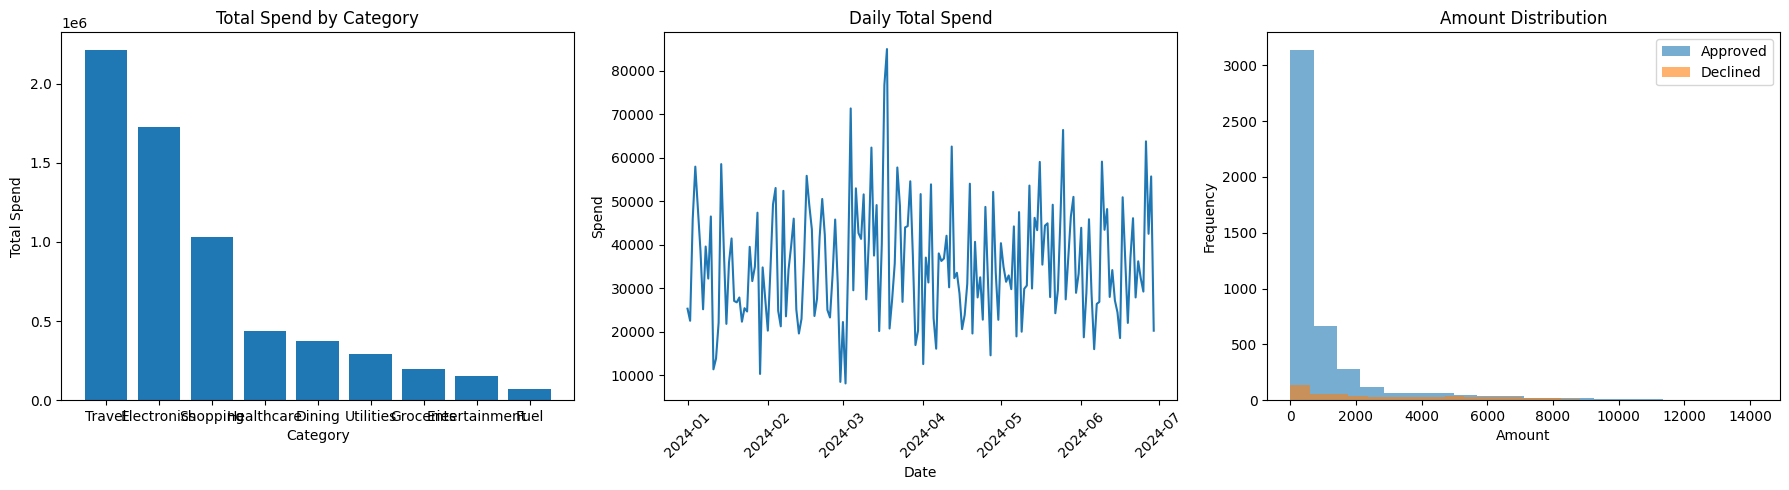

In [12]:
fig, axes = plt.subplots(1,3,figsize=(18,5))

category_spend = df.groupby('category')['amount'].sum().sort_values(ascending=False)
axes[0].bar(category_spend.index, category_spend.values)
axes[0].set_title('Total Spend by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Spend')

daily_spend = df.groupby(df['datetime'].dt.date)['amount'].sum()
axes[1].plot(daily_spend.index, daily_spend.values)
axes[1].set_title('Daily Total Spend')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Spend')
axes[1].tick_params(axis='x', rotation=45)

approved_amounts = df[df['status']=='approved']['amount']
declined_amounts = df[df['status']=='declined']['amount']
axes[2].hist(approved_amounts,bins=20,alpha=0.6,label='Approved')
axes[2].hist(declined_amounts,bins=20,alpha=0.6,label='Declined')
axes[2].legend()
axes[2].set_title('Amount Distribution')
axes[2].set_xlabel('Amount')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
